# Dự đoán mức tiêu hao nhiên liệu của xe
## 1. Bài toán và cách học
Đây là hồi quy có giám sát: X là thông số xe, y là số lít/100 km. Mục tiêu là dự đoán xe chưa xuất hiện trong train. Bạn chạy từng cell, đọc kết quả rồi thử giải thích trước khi đi tiếp.

Dữ liệu UCI Auto MPG có 398 xe lịch sử, tiêu hao đô thị. Dự án không đo tiêu hao chuyến đi thực tế. Nguồn: https://archive.ics.uci.edu/dataset/9/auto+mpg .

Đơn vị: dung tích lít, trọng lượng kg, công suất hp, tăng tốc 0–60 mph tính bằng giây, năm đầy đủ. Công thức mục tiêu: `235.214583 / MPG`.

In [14]:
from pathlib import Path
import sys
ROOT = Path.cwd()
if not (ROOT / 'src' / 'fuel.py').exists():
    ROOT = ROOT.parent
assert (ROOT / 'src' / 'fuel.py').exists(), 'Mở notebook từ thư mục dự án hoặc notebooks'
sys.path.insert(0, str(ROOT / 'src'))
import fuel
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown
print('Python:', sys.executable)

Python: E:\machine-learing\.venv\Scripts\python.exe


In [15]:
from pathlib import Path
import sys
ROOT = Path.cwd()
if not (ROOT / 'src' / 'fuel.py').exists():
    ROOT = ROOT.parent
assert (ROOT / 'src' / 'fuel.py').exists(), 'Mở notebook từ thư mục dự án hoặc notebooks'
sys.path.insert(0, str(ROOT / 'src'))
import fuel
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown
print('Python:', sys.executable)

Python: E:\machine-learing\.venv\Scripts\python.exe


## 2. Khám phá và chất lượng dữ liệu
`pandas` đọc bảng; NumPy tính toán; Matplotlib trực quan hóa. Kiểm tra dữ liệu thiếu trước khi chọn cách xử lý. Không xóa tất cả xe thiếu horsepower: pipeline sẽ điền median từ train.

Khám phá toàn bộ dữ liệu dưới đây chỉ để mô tả. Các lựa chọn mô hình đã được cố định trước; không dùng kết quả test để điều chỉnh.

In [16]:
df = fuel.load_data()
display(df.head())
display(df[fuel.FEATURES + [fuel.TARGET]].describe(include='all'))
display(df.isna().sum().to_frame('missing'))
assert len(df) == 398
print('Số công suất thiếu:', df.horsepower.isna().sum())

,mpg,cylinders,displacement,horsepower,weight,acceleration_s,model_year,origin,car_name,displacement_l,weight_kg,fuel_l_per_100km
0,18.0,8,307.0,130.0,3504.0,12.0,1970,usa,chevrolet chevelle malibu,5.030829,1589.387664,13.067477
1,15.0,8,350.0,165.0,3693.0,11.5,1970,usa,buick skylark 320,5.735472,1675.116622,15.680972
2,18.0,8,318.0,150.0,3436.0,11.0,1970,usa,plymouth satellite,5.211086,1558.543383,13.067477
3,16.0,8,304.0,150.0,3433.0,12.0,1970,usa,amc rebel sst,4.981667,1557.182606,14.700911
4,17.0,8,302.0,140.0,3449.0,10.5,1970,usa,ford torino,4.948893,1564.440084,13.836152


,cylinders,displacement_l,horsepower,weight_kg,acceleration_s,model_year,origin,fuel_l_per_100km
count,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398,398.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,usa,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,249,NaN
mean,5.454774,3.169682,104.469388,1347.361945,15.568090,1976.010050,NaN,11.213056
std,1.701004,1.708677,38.491160,384.120967,2.757689,3.697627,NaN,3.902082
min,3.000000,1.114320,46.000000,731.644493,8.000000,1970.000000,NaN,5.047523
25%,4.000000,1.708351,75.000000,1008.676033,13.825000,1973.000000,NaN,8.110848
50%,4.000000,2.433479,93.500000,1271.646209,15.500000,1976.000000,NaN,10.226721
75%,8.000000,4.293411,126.000000,1636.561271,17.175000,1979.000000,NaN,13.440833


,missing
mpg,0
cylinders,0
displacement,0
horsepower,6
weight,0
acceleration_s,0
model_year,0
origin,0
car_name,0
displacement_l,0


Số công suất thiếu: 6


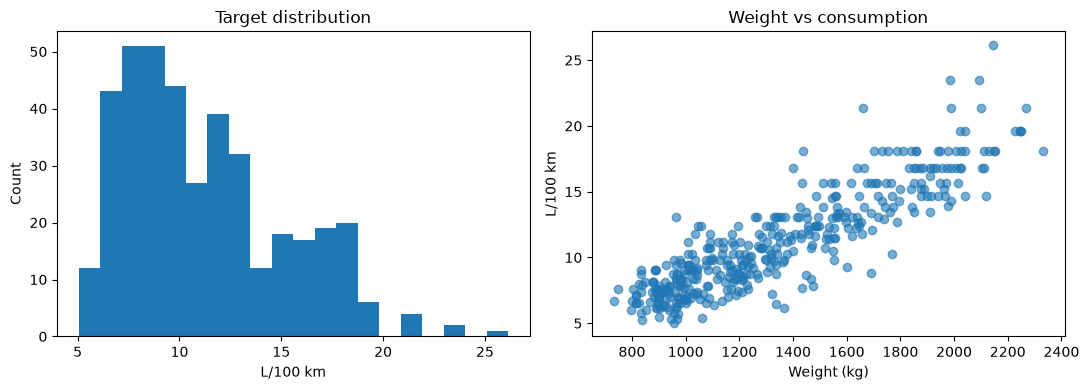

,cylinders,displacement_l,horsepower,weight_kg,acceleration_s,model_year,fuel_l_per_100km
cylinders,1.00,0.95,0.84,0.90,-0.51,-0.35,0.84
displacement_l,0.95,1.00,0.90,0.93,-0.54,-0.37,0.87
horsepower,0.84,0.90,1.00,0.86,-0.69,-0.42,0.85
weight_kg,0.90,0.93,0.86,1.00,-0.42,-0.31,0.89
acceleration_s,-0.51,-0.54,-0.69,-0.42,1.00,0.29,-0.46
model_year,-0.35,-0.37,-0.42,-0.31,0.29,1.00,-0.56
fuel_l_per_100km,0.84,0.87,0.85,0.89,-0.46,-0.56,1.00


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df[fuel.TARGET], bins=20)
axes[0].set(xlabel='L/100 km', ylabel='Count', title='Target distribution')
axes[1].scatter(df.weight_kg, df[fuel.TARGET], alpha=.6)
axes[1].set(xlabel='Weight (kg)', ylabel='L/100 km', title='Weight vs consumption')
plt.tight_layout()
plt.show()
# Tương quan mô tả, không chứng minh quan hệ nhân quả.
display(df[fuel.NUMERIC + [fuel.TARGET]].corr().round(2))

## 3. Chia dữ liệu và pipeline
Giữ 20% test riêng. 80% train được chia thành 5 fold để lựa chọn mô hình. Median, scaling và encoding đều học bên trong từng fold, tránh rò rỉ dữ liệu.

Baseline luôn dự đoán trung bình. Ridge là mô hình tuyến tính có regularization; Random Forest kết hợp 300 cây để học quan hệ phi tuyến. So sánh bằng MAE (càng nhỏ càng tốt).

`fuel.train()` thực hiện toàn bộ quy trình chung với CLI, chọn bằng CV rồi mới đánh giá test. Cell này cũng lưu mô hình và báo cáo; có thể cần vài phút.

In [10]:
result = fuel.train()
display(result['comparison'])
print('Số train/test:', len(result['X_train']), len(result['X_test']))
display(result['model'])

,model,cv_mae,cv_std,parameters
0,random_forest,0.926575,0.107210,"{""model__max_depth"": null, ""model__min_samples..."
1,ridge,0.990205,0.122347,"{""model__alpha"": 10}"
2,baseline,3.231143,0.186889,{}


Số train/test: 318 80


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['cylinders','displacement_l','horsepower',...,'acceleration_s', 'model_year','origin']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('category', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. T

## 4. Đánh giá trên test
MAE là sai số tuyệt đối trung bình; RMSE phạt mạnh lỗi lớn. Cả hai có đơn vị L/100 km. R² so sánh sai số với biến thiên dữ liệu, không phải tỷ lệ dự đoán đúng.

Biểu đồ càng gần đường chéo càng tốt. Sai số dương là dự đoán quá cao. Chỉ xem test sau khi chọn mô hình; không dùng nó để tiếp tục tuning.

mae     0.832825
rmse    1.200645
r2      0.906014
Name: test_metrics, dtype: float64

Baseline test MAE: 3.1448423947279616


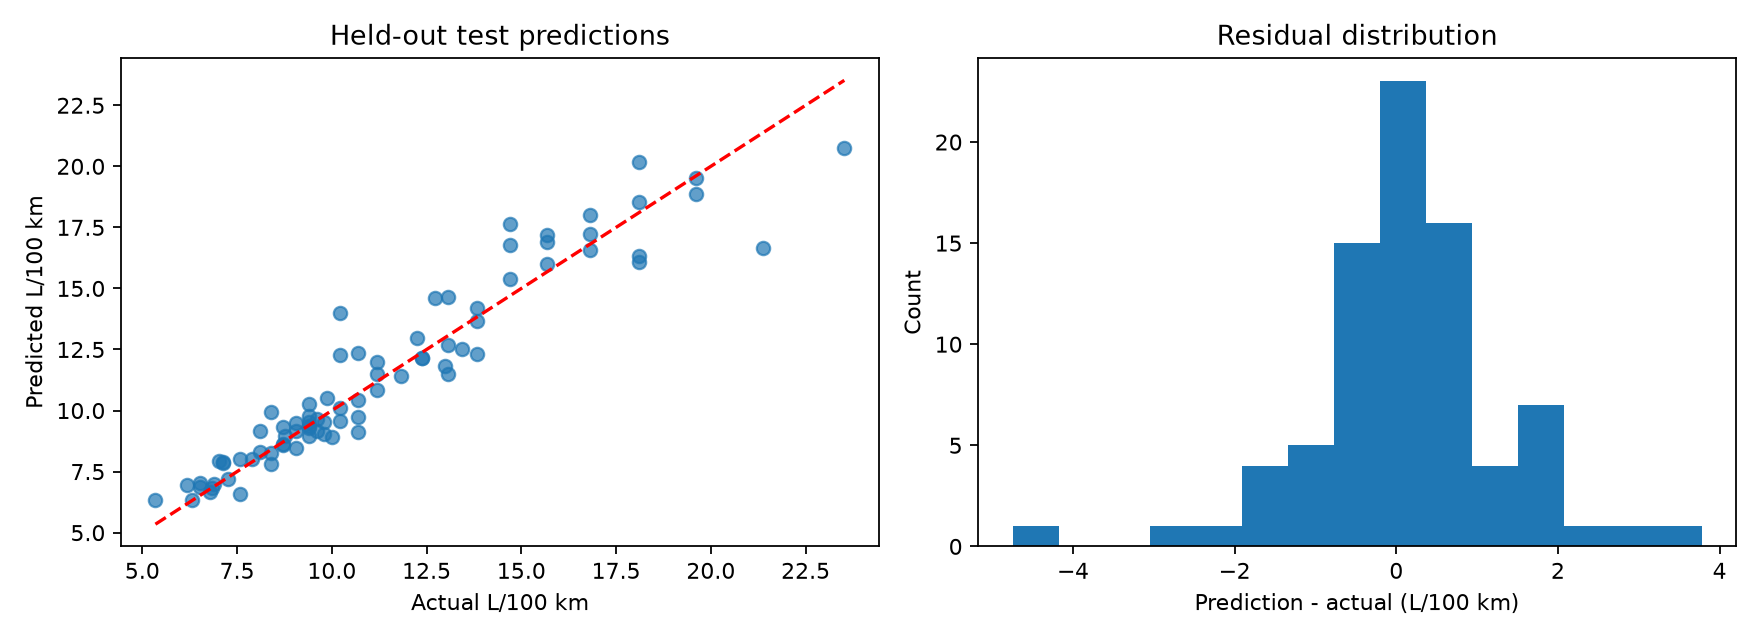

# Kết quả đánh giá

Mô hình chọn bằng cross-validation: **random_forest**.

Train: 318 xe; test: 80 xe.

MAE test: **0.833 L/100 km**. RMSE: 1.201; R²: 0.906.

MAE baseline test: 3.145 L/100 km.

        model   cv_mae   cv_std                                               parameters
random_forest 0.926575 0.107210 {"model__max_depth": null, "model__min_samples_leaf": 1}
        ridge 0.990205 0.122347                                     {"model__alpha": 10}
     baseline 3.231143 0.186889                                                       {}

Permutation importance được tính trên train, chỉ mang tính khám phá và có thể lạc quan; không chứng minh quan hệ nhân quả.

Dữ liệu xe 1970–1982 trong chu trình đô thị; chưa được xác thực cho xe hiện đại, xe điện hoặc chuyến đi thực tế. Chia ngẫu nhiên đánh giá xe trong cùng phân phối lịch sử, không đánh giá khả năng dự đoán tương lai.


In [11]:
display(pd.Series(result['metadata']['metrics'], name='test_metrics'))
print('Baseline test MAE:', result['metadata']['baseline_test_mae'])
display(Image(filename=str(ROOT / 'reports' / 'evaluation.png')))
display(Markdown((ROOT / 'reports' / 'results.md').read_text(encoding='utf-8')))

## 5. Phân tích lỗi và tầm quan trọng đặc điểm
Xem các xe có lỗi lớn: mô hình sai nhiều ở nhóm nào? Permutation importance đảo ngẫu nhiên một cột và đo mức MAE tăng. Giá trị lớn cho thấy mô hình phụ thuộc nhiều vào cột đó.

Importance tính trên train để không dùng test cho lựa chọn. Nó có thể lạc quan, bị ảnh hưởng bởi tương quan giữa các đặc điểm và không chứng minh nguyên nhân.

,car_name,cylinders,displacement_l,horsepower,weight_kg,acceleration_s,model_year,origin,actual,predicted,absolute_error
124,oldsmobile omega,8,5.735472,180.0,1661.962444,11.0,1973,usa,21.383144,16.636715,4.746429
298,cadillac eldorado,8,5.735472,125.0,1769.010243,17.4,1979,usa,10.226721,14.003651,3.776930
116,pontiac grand prix,8,6.554826,230.0,1940.468159,9.5,1973,usa,14.700911,17.637002,2.936091
25,ford f250,8,5.899343,215.0,2093.328788,14.0,1970,usa,23.521458,20.751632,2.769826
94,chrysler new yorker brougham,8,7.210308,215.0,2147.759872,11.0,1973,usa,18.093429,20.168008,2.074578
158,plymouth grand fury,8,5.211086,150.0,2040.258480,14.5,1975,usa,14.700911,16.772868,2.071957
101,plymouth duster,6,3.244639,95.0,1317.232242,16.0,1973,usa,10.226721,12.292427,2.065706
208,plymouth volare premier v8,8,5.211086,150.0,1787.153938,13.2,1976,usa,18.093429,16.086101,2.007328
292,chrysler lebaron town @ country (sw),8,5.899343,150.0,1787.153938,13.0,1979,usa,12.714302,14.623485,1.909184
73,chevrolet chevelle concours (sw),8,5.030829,130.0,1858.821532,14.0,1972,usa,18.093429,16.313900,1.779529


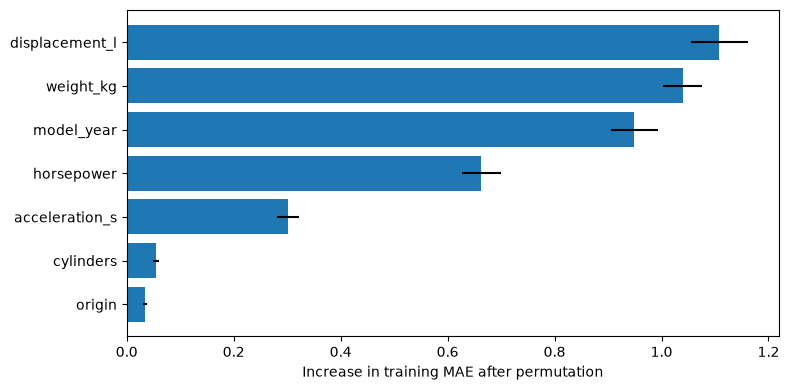

In [12]:
display(result['errors'].sort_values('absolute_error', ascending=False).head(10))
importance = result['importance'].sort_values('importance')
plt.figure(figsize=(8, 4))
plt.barh(importance.feature, importance.importance, xerr=importance['std'])
plt.xlabel('Increase in training MAE after permutation')
plt.tight_layout()
plt.savefig(ROOT / 'reports' / 'importance.png', dpi=160)
plt.show()

## 6. Dự đoán xe mới và kiểm tra lưu mô hình
Mô hình đã lưu gồm cả preprocessing. Khi dự đoán phải dùng cùng tên cột và đơn vị. Thiếu công suất được phép; thiếu các thông số khác sẽ báo lỗi. Thông số ngoài khoảng train được cảnh báo.

Ví dụ dùng xe lịch sử tương tự dữ liệu train. Bạn có thể đổi năm sang 2025 để xem cảnh báo, nhưng dự đoán cho xe hiện đại chưa được xác thực.

In [13]:
import json
import joblib
vehicle = json.loads((ROOT / 'examples' / 'vehicle.json').read_text())
display(vehicle)
display(fuel.predict(vehicle))
loaded = joblib.load(ROOT / 'models' / 'fuel_pipeline.joblib')
np.testing.assert_allclose(result['model'].predict(result['X_test']), loaded.predict(result['X_test']))
print('Mô hình trước và sau lưu cho dự đoán giống nhau.')

{'cylinders': 4,
 'displacement_l': 1.6,
 'horsepower': 88,
 'weight_kg': 1100,
 'acceleration_s': 15.5,
 'model_year': 1980,
 'origin': 'japan'}

{'fuel_l_per_100km': 7.007327681813514,
 'model': 'random_forest',
 'warnings': [],
 'context': 'Historical urban-cycle data; not validated for modern vehicles.'}

Mô hình trước và sau lưu cho dự đoán giống nhau.


## 7. Tự luyện và giới hạn
1. Giải thích vì sao xe nặng thường tiêu hao nhiều hơn trong bảng dữ liệu.
2. Thử xe thiếu horsepower và kiểm tra pipeline.
3. Trong một thí nghiệm mới, so sánh cấu hình bằng CV trên train; đừng dùng test đã xem như đánh giá độc lập.

Dữ liệu chỉ 398 xe năm 1970–1982, không có hộp số, tắc đường, phong cách lái hay xe điện. Split ngẫu nhiên đánh giá cùng phân phối lịch sử, chưa đánh giá khả năng dự báo tương lai. Muốn dùng thực tế cần dữ liệu mới và đánh giá độc lập.

Xem README để chạy CLI và xem `reports/` để đọc báo cáo, dự đoán từng xe và biểu đồ.